# Olist Marketplace Performance & Customer Focused Analysis

**Prepared for:** Olist Operations & Customer Experience Leadership
**Role:** Data Analyst
**Scope:** ~100,000 orders, Sep 2016 – Oct 2018, across 9 linked tables (orders, items, payments, reviews, customers, products, sellers, geolocation, category translation)

This notebook is built to run **top to bottom without errors** once the 9 source CSVs are placed in `./data/`. It follows: Data Understanding → Data Cleaning → EDA → Analysis of the 6 Core Questions (+ optional deep dives) → Visualizations → Key Findings.

**Library choice:** core numeric work uses **NumPy** directly (rates, deltas, correlations, a NumPy least-squares regression for the root-cause section) rather than leaning on higher-level stats libraries; all charts are **Matplotlib** (no seaborn/plotly), so the visual style is fully under our control and dependency-light.


In [ ]:
import numpy as np
import pandas as pd  
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 10

DATA_DIR = Path('./data')  
RNG = np.random.default_rng(42)


## 1. Data Understanding

In [2]:
FILES = {
    'orders':       'olist_orders_dataset.csv',
    'items':        'olist_order_items_dataset.csv',
    'payments':     'olist_order_payments_dataset.csv',
    'reviews':      'olist_order_reviews_dataset.csv',
    'customers':    'olist_customers_dataset.csv',
    'products':     'olist_products_dataset.csv',
    'sellers':      'olist_sellers_dataset.csv',
    'geo':          'olist_geolocation_dataset.csv',
    'cat_translate':'product_category_name_translation.csv',
}

missing = [name for name, f in FILES.items() if not (DATA_DIR / f).exists()]
if missing:
    raise FileNotFoundError(
        f"Missing source file(s): {missing}. Place all 9 Olist CSVs in {DATA_DIR.resolve()} and re-run."
    )

orders    = pd.read_csv(DATA_DIR / FILES['orders'],    parse_dates=[
                'order_purchase_timestamp','order_approved_at',
                'order_delivered_carrier_date','order_delivered_customer_date',
                'order_estimated_delivery_date'])
items     = pd.read_csv(DATA_DIR / FILES['items'])
payments  = pd.read_csv(DATA_DIR / FILES['payments'])
reviews   = pd.read_csv(DATA_DIR / FILES['reviews'], parse_dates=['review_creation_date','review_answer_timestamp'])
customers = pd.read_csv(DATA_DIR / FILES['customers'])
products  = pd.read_csv(DATA_DIR / FILES['products'])
sellers   = pd.read_csv(DATA_DIR / FILES['sellers'])
geo       = pd.read_csv(DATA_DIR / FILES['geo'])
cat_map   = pd.read_csv(DATA_DIR / FILES['cat_translate'])

tables = dict(orders=orders, items=items, payments=payments, reviews=reviews,
              customers=customers, products=products, sellers=sellers, geo=geo, cat_map=cat_map)

print(f"{'table':<12}{'rows':>10}{'cols':>8}")
for name, df in tables.items():
    print(f"{name:<12}{len(df):>10,}{df.shape[1]:>8}")


table             rows    cols
orders          99,441       8
items          112,650       6
payments       103,886       5
reviews        100,000       7
customers       99,441       5
products        32,951       9
sellers          3,095       4
geo          1,000,163       5
cat_map             71       2


In [3]:
print("Missing values (count / % of rows):\n")
for name, df in tables.items():
    n = len(df)
    miss = df.isna().sum()
    miss = miss[miss > 0]
    if len(miss) == 0:
        continue
    print(f"-- {name} --")
    pct = (miss.values / n * 100).round(2)
    for col, cnt, p in zip(miss.index, miss.values, pct):
        print(f"   {col:<32}{cnt:>8,}  ({p}%)")
    print()


Missing values (count / % of rows):

-- orders --
   order_approved_at                    160  (0.16%)
   order_delivered_carrier_date       1,783  (1.79%)
   order_delivered_customer_date      2,965  (2.98%)

-- reviews --
   review_comment_title              88,285  (88.28%)
   review_comment_message            58,247  (58.25%)

-- products --
   product_category_name                610  (1.85%)
   product_name_lenght                  610  (1.85%)
   product_description_lenght           610  (1.85%)
   product_photos_qty                   610  (1.85%)
   product_weight_g                       2  (0.01%)
   product_length_cm                      2  (0.01%)
   product_height_cm                      2  (0.01%)
   product_width_cm                       2  (0.01%)



In [4]:
print(orders['order_status'].value_counts())
print("\nDate range:", orders['order_purchase_timestamp'].min(), '->', orders['order_purchase_timestamp'].max())
print("\nUnique customer_id       :", customers['customer_id'].nunique())
print("Unique customer_unique_id:", customers['customer_unique_id'].nunique(),
      " (repeat customers exist: order-level IDs > person-level IDs)")


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Date range: 2016-09-04 21:15:19 -> 2018-10-17 17:30:18

Unique customer_id       : 99441
Unique customer_unique_id: 96096  (repeat customers exist: order-level IDs > person-level IDs)


## 2. Data Cleaning

Decisions made explicitly (per the dataset's known quirks) rather than silently:

- **Non-delivered orders** (`order_status != 'delivered'`) are kept for volume/revenue trend analysis but **excluded** from any delivery-timing analysis, since ~93% lack a `order_delivered_customer_date` by nature of the status.
- **Missing timestamps** on otherwise-delivered orders are dropped only from the specific calculation that needs them (not from the whole dataset).
- **Geolocation** is aggregated to one row per zip prefix (mean lat/lng) *before* joining, since raw rows are ~52:1 vs. unique prefixes.
- **Category translation** is merged in; the ~610 products missing a category are labeled `unknown`.
- **customer_unique_id**, not `customer_id`, is used for anything about repeat customers.


In [5]:
# Order-level revenue (sum item price + freight) and item counts
order_items_agg = items.groupby('order_id').agg(
    n_items=('order_item_id', 'count'),
    item_price_total=('price', 'sum'),
    freight_total=('freight_value', 'sum'),
).reset_index()

# Order-level payment total (sum across split/combined payments)
order_payment_agg = payments.groupby('order_id').agg(
    payment_total=('payment_value', 'sum'),
    n_payment_records=('payment_sequential', 'count'),
    max_installments=('payment_installments', 'max'),
).reset_index()
# Dominant payment_type per order = the one with the largest single payment_value
dominant_pay = (payments.sort_values('payment_value', ascending=False)
                         .drop_duplicates('order_id')[['order_id','payment_type']])

# Category (English) per product
products_c = products.merge(cat_map, on='product_category_name', how='left')
products_c['product_category_name_english'] = products_c['product_category_name_english'].fillna('unknown')

# Geolocation aggregated to one row per zip prefix
geo_agg = geo.groupby('geolocation_zip_code_prefix').agg(
    lat=('geolocation_lat', 'mean'),
    lng=('geolocation_lng', 'mean'),
).reset_index()

# Delivery delta in days: negative = early, positive = late (delivered orders only)
delivered = orders[orders['order_status'] == 'delivered'].copy()
delivered = delivered.dropna(subset=['order_delivered_customer_date', 'order_estimated_delivery_date'])
delivered['delivery_delay_days'] = (
    (delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date'])
    .dt.total_seconds() / 86400.0
)
delivered['purchase_to_delivery_days'] = (
    (delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp'])
    .dt.total_seconds() / 86400.0
)

print(f"Delivered orders with complete timestamps: {len(delivered):,} / {len(orders):,} total orders")
print(f"Mean delivery delay vs. estimate: {np.mean(delivered['delivery_delay_days']):.2f} days "
      f"(negative = early)")


Delivered orders with complete timestamps: 96,470 / 99,441 total orders
Mean delivery delay vs. estimate: -11.18 days (negative = early)


In [6]:
# Master analysis table: one row per order, joined across all dimensions
order_rev = reviews.sort_values('review_answer_timestamp').drop_duplicates('order_id', keep='last')

master = (orders
    .merge(order_items_agg, on='order_id', how='left')
    .merge(order_payment_agg, on='order_id', how='left')
    .merge(dominant_pay, on='order_id', how='left')
    .merge(order_rev[['order_id','review_score','review_comment_message']], on='order_id', how='left')
    .merge(customers, on='customer_id', how='left')
)

# Primary product/seller/category per order = from the highest-value item (simplification for mixed-category orders)
main_item = (items.merge(products_c[['product_id','product_category_name_english','product_weight_g',
                                       'product_length_cm','product_height_cm','product_width_cm']],
                          on='product_id', how='left')
                   .sort_values('price', ascending=False)
                   .drop_duplicates('order_id', keep='first'))
main_item = main_item.merge(sellers, on='seller_id', how='left')

master = master.merge(
    main_item[['order_id','seller_id','seller_state','seller_city',
               'product_category_name_english','product_weight_g']],
    on='order_id', how='left'
)

master['order_value'] = master['item_price_total'].fillna(0) + master['freight_total'].fillna(0)

# Fixed delivery_delay_days mapping using direct Series.map()
master['delivery_delay_days'] = master['order_id'].map(
    delivered.set_index('order_id')['delivery_delay_days']
)

master['on_time'] = np.where(master['delivery_delay_days'].isna(), np.nan,
                              (master['delivery_delay_days'] <= 0).astype(float))

print(f"Master table: {len(master):,} rows (should equal orders row count: {len(orders):,})")
master[['order_id','order_status','review_score','order_value','delivery_delay_days',
        'customer_state','seller_state','product_category_name_english']].head()


Master table: 99,441 rows (should equal orders row count: 99,441)


,order_id,order_status,review_score,order_value,delivery_delay_days,customer_state,seller_state,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,4,38.71,-7.107488,SP,SP,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,4,141.46,-5.355729,BA,SP,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,5,179.12,-17.245498,GO,SP,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,5,72.20,-12.980069,RN,MG,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,5,28.62,-9.238171,SP,SP,stationery


## 3. Exploratory Data Analysis

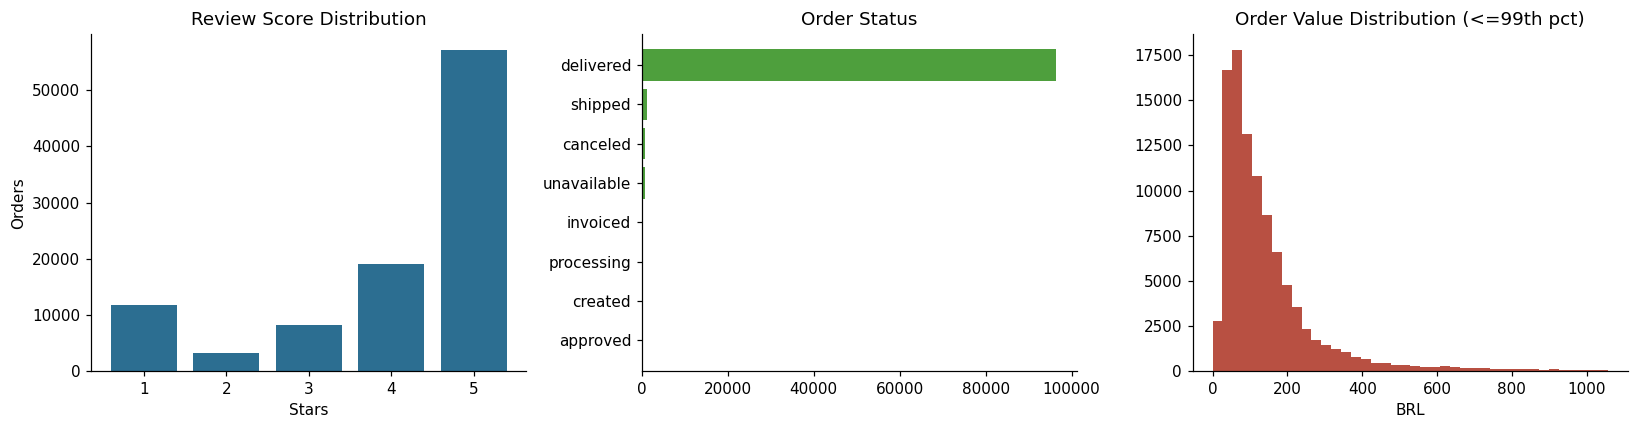

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Review score distribution
scores, counts = np.unique(master['review_score'].dropna(), return_counts=True)
axes[0].bar(scores, counts, color='#2C6E91')
axes[0].set_title('Review Score Distribution')
axes[0].set_xlabel('Stars'); axes[0].set_ylabel('Orders')
axes[0].set_xticks([1,2,3,4,5])

# Order status
status_counts = master['order_status'].value_counts()
axes[1].barh(status_counts.index, status_counts.values, color='#4E9F3D')
axes[1].set_title('Order Status')
axes[1].invert_yaxis()

# Order value distribution (log x, trimmed at 99th pct for readability)
vals = master['order_value'].dropna()
cap = np.percentile(vals, 99)
axes[2].hist(vals[vals <= cap], bins=40, color='#B85042')
axes[2].set_title('Order Value Distribution (<=99th pct)')
axes[2].set_xlabel('BRL')

plt.tight_layout(); plt.show()


## 4. Core Question 1 — Marketplace Performance Over Time

Monthly order volume, revenue, and average review score, plotted together to see whether growth and satisfaction move in the same direction.

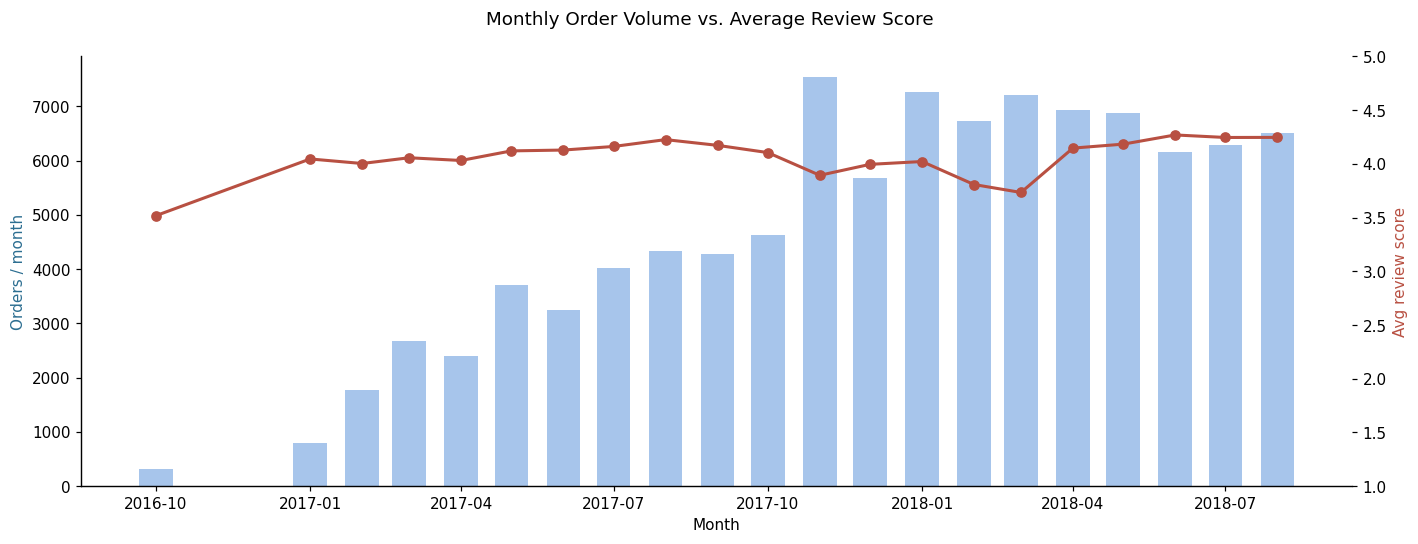

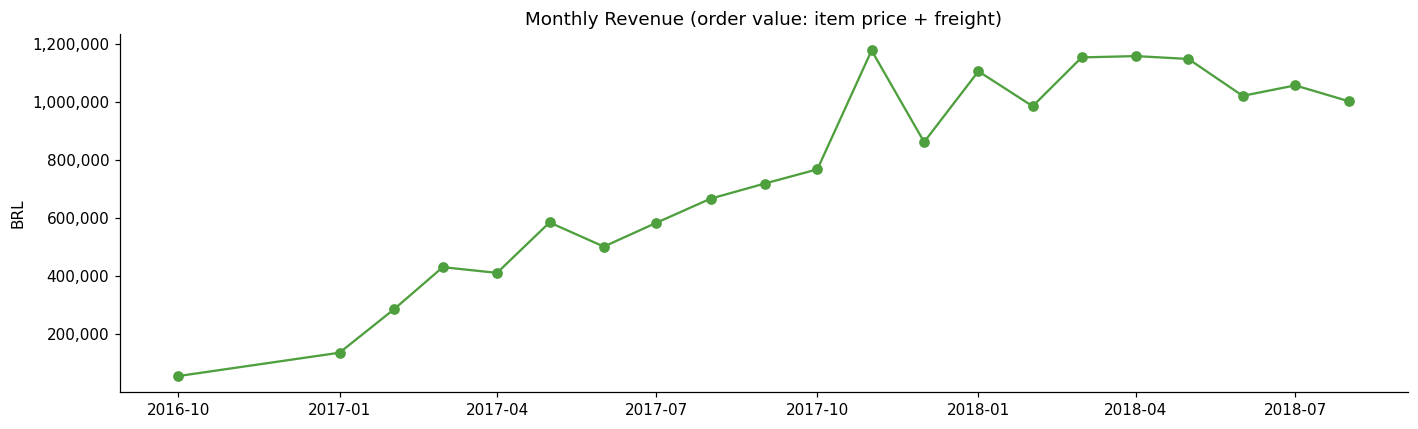

Correlation between monthly order volume and avg review score: 0.212


In [8]:
m = master.dropna(subset=['order_purchase_timestamp']).copy()
m['month'] = m['order_purchase_timestamp'].values.astype('datetime64[M]')

monthly = m.groupby('month').agg(
    orders=('order_id', 'count'),
    revenue=('order_value', 'sum'),
    avg_review=('review_score', 'mean'),
).reset_index()
# Drop the first/last partial months if they look like ramp-up/cutoff artifacts
monthly = monthly[(monthly['orders'] > monthly['orders'].max() * 0.01)]

fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.bar(monthly['month'], monthly['orders'], width=20, color='#A7C5EB', label='Orders')
ax1.set_ylabel('Orders / month', color='#2C6E91')
ax1.set_xlabel('Month')

ax2 = ax1.twinx()
ax2.plot(monthly['month'], monthly['avg_review'], color='#B85042', marker='o', linewidth=2, label='Avg review score')
ax2.set_ylabel('Avg review score', color='#B85042')
ax2.set_ylim(1, 5)

fig.suptitle('Monthly Order Volume vs. Average Review Score')
fig.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(monthly['month'], monthly['revenue'], color='#4E9F3D', marker='o')
ax.set_title('Monthly Revenue (order value: item price + freight)')
ax.set_ylabel('BRL'); ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.tight_layout(); plt.show()

corr = np.corrcoef(monthly['orders'], monthly['avg_review'])[0,1]
print(f"Correlation between monthly order volume and avg review score: {corr:.3f}")


## 5. Core Question 2 — Delivery Performance and Customer Focused

Bucket delivery delay (days late/early vs. the estimate) and compare average review scores, then check whether the relationship holds across categories and regions.

                       mean  count
delay_bucket                      
7+ days early      4.306312  71303
2-7 days early     4.201898  14329
On time/1-2 early  4.129150   3012
1-2 days late      3.899858   2117
2-7 days late      2.496193   2364
7+ days late       1.721973   3345


/tmp/ipykernel_4900/4133340835.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_stats = d.groupby('delay_bucket')['review_score'].agg(['mean','count'])


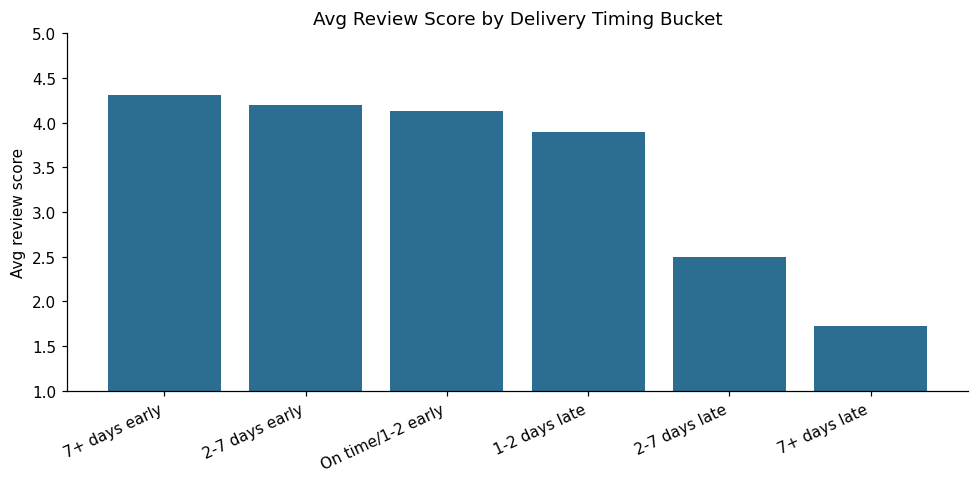


Overall correlation (delay days vs review score): -0.269

Correlation by customer state (delay vs review, states with >=200 orders):
CE   -0.472818
AL   -0.467077
PA   -0.419675
RJ   -0.405222
PE   -0.400733
SE   -0.400277
RN   -0.400105
MS   -0.371734
MA   -0.368735
PB   -0.350476
PI   -0.321945
SC   -0.321945
GO   -0.299810
BA   -0.298612
ES   -0.294301
TO   -0.286348
DF   -0.257511
RS   -0.247062
MT   -0.220487
MG   -0.215653
SP   -0.182976
RO   -0.180183
PR   -0.175003
dtype: float64


In [9]:
d = master.dropna(subset=['delivery_delay_days','review_score']).copy()

bins = [-np.inf, -7, -2, 0, 2, 7, np.inf]
labels = ['7+ days early', '2-7 days early', 'On time/1-2 early', '1-2 days late', '2-7 days late', '7+ days late']
d['delay_bucket'] = pd.cut(d['delivery_delay_days'], bins=bins, labels=labels)

bucket_stats = d.groupby('delay_bucket')['review_score'].agg(['mean','count'])
print(bucket_stats)

fig, ax = plt.subplots(figsize=(9,4.5))
ax.bar(bucket_stats.index.astype(str), bucket_stats['mean'], color='#2C6E91')
ax.set_ylabel('Avg review score'); ax.set_ylim(1,5)
ax.set_title('Avg Review Score by Delivery Timing Bucket')
plt.xticks(rotation=25, ha='right')
plt.tight_layout(); plt.show()

# Correlation, overall
corr_all = np.corrcoef(d['delivery_delay_days'], d['review_score'])[0,1]
print(f"\nOverall correlation (delay days vs review score): {corr_all:.3f}")

# Does it hold across regions? correlation per customer_state (states with >=200 orders)
state_n = d['customer_state'].value_counts()
valid_states = state_n[state_n >= 200].index
by_state = {s: np.corrcoef(d.loc[d['customer_state']==s,'delivery_delay_days'],
                            d.loc[d['customer_state']==s,'review_score'])[0,1]
            for s in valid_states}
by_state = pd.Series(by_state).sort_values()
print("\nCorrelation by customer state (delay vs review, states with >=200 orders):")
print(by_state)


## 6. Core Question 3 — Seller and Geographic Patterns

Order concentration, delivery delay, and freight cost by state, plus an approximate seller-customer distance using the aggregated geolocation table (haversine distance, computed in NumPy).

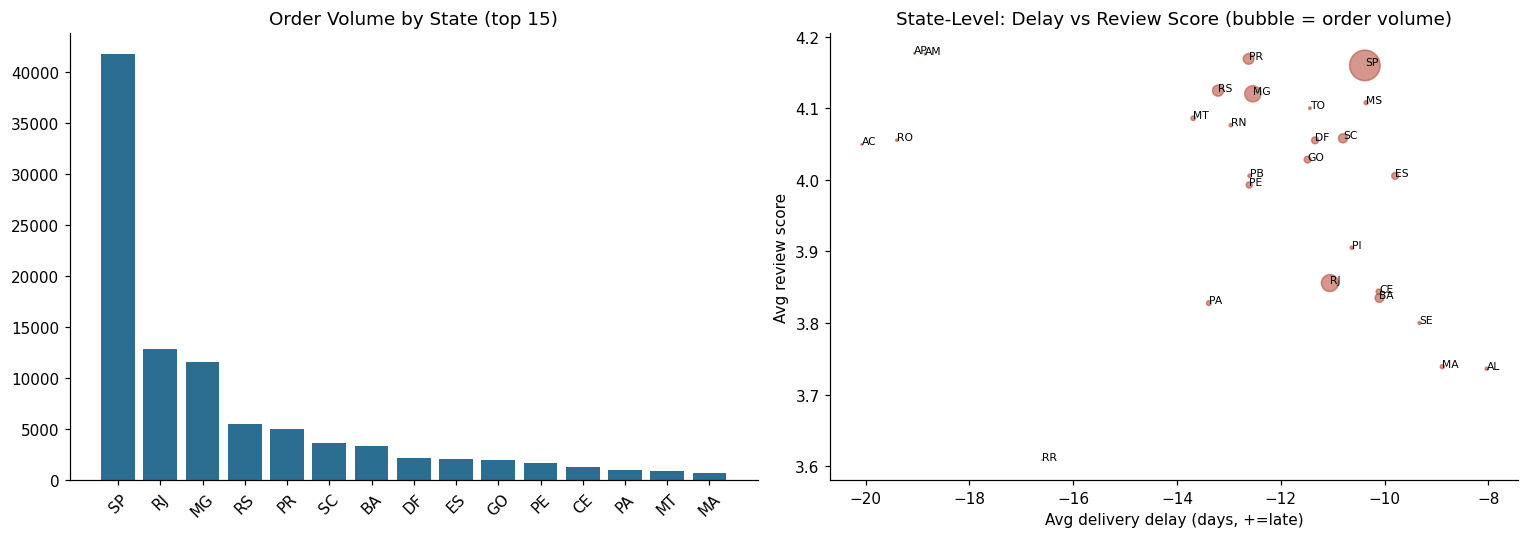

In [10]:
state_perf = master.groupby('customer_state').agg(
    orders=('order_id','count'),
    avg_review=('review_score','mean'),
    avg_delay=('delivery_delay_days','mean'),
    avg_freight=('freight_total','mean'),
).sort_values('orders', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14,5))
top_states = state_perf.head(15)
axes[0].bar(top_states.index, top_states['orders'], color='#2C6E91')
axes[0].set_title('Order Volume by State (top 15)'); axes[0].tick_params(axis='x', rotation=45)

axes[1].scatter(state_perf['avg_delay'], state_perf['avg_review'], s=state_perf['orders']/state_perf['orders'].max()*400,
                alpha=0.6, color='#B85042')
for s, row in state_perf.iterrows():
    axes[1].annotate(s, (row['avg_delay'], row['avg_review']), fontsize=7)
axes[1].set_xlabel('Avg delivery delay (days, +=late)'); axes[1].set_ylabel('Avg review score')
axes[1].set_title('State-Level: Delay vs Review Score (bubble = order volume)')

plt.tight_layout(); plt.show()


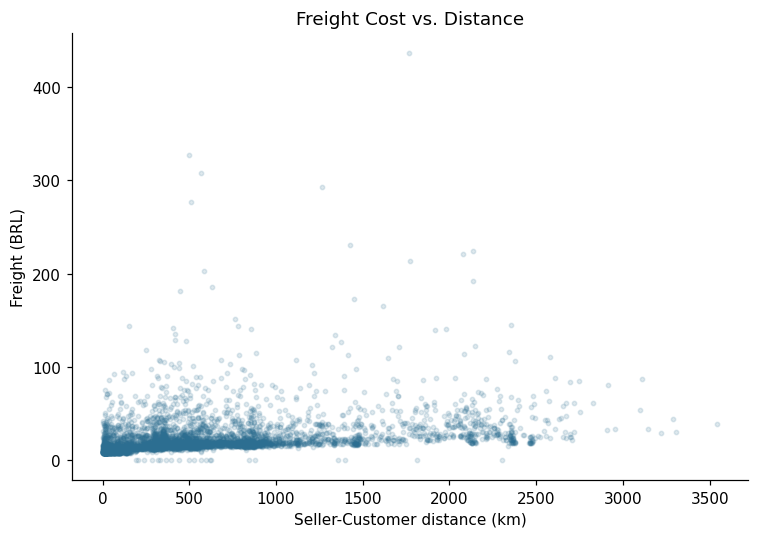

Correlation distance vs freight: 0.313
Correlation distance vs delivery delay: -0.074


In [11]:
def haversine_km(lat1, lon1, lat2, lon2):
    # Pure-NumPy great-circle distance
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

dist_df = (master[['order_id','customer_zip_code_prefix']]
           .merge(main_item[['order_id','seller_id']], on='order_id', how='left')
           .merge(sellers[['seller_id','seller_zip_code_prefix']], on='seller_id', how='left')
           .merge(geo_agg.rename(columns={'geolocation_zip_code_prefix':'customer_zip_code_prefix',
                                            'lat':'cust_lat','lng':'cust_lng'}),
                  on='customer_zip_code_prefix', how='left')
           .merge(geo_agg.rename(columns={'geolocation_zip_code_prefix':'seller_zip_code_prefix',
                                            'lat':'sell_lat','lng':'sell_lng'}),
                  on='seller_zip_code_prefix', how='left')
           .dropna(subset=['cust_lat','cust_lng','sell_lat','sell_lng']))

dist_df['distance_km'] = haversine_km(dist_df['cust_lat'], dist_df['cust_lng'],
                                       dist_df['sell_lat'], dist_df['sell_lng'])

dist_df = dist_df.merge(master[['order_id','freight_total','delivery_delay_days','review_score']], on='order_id')

fig, ax = plt.subplots(figsize=(7,5))
sample = dist_df.sample(min(5000, len(dist_df)), random_state=0)
ax.scatter(sample['distance_km'], sample['freight_total'], alpha=0.15, s=8, color='#2C6E91')
ax.set_xlabel('Seller-Customer distance (km)'); ax.set_ylabel('Freight (BRL)')
ax.set_title('Freight Cost vs. Distance')
plt.tight_layout(); plt.show()

corr_dist_freight = np.corrcoef(dist_df['distance_km'], dist_df['freight_total'])[0,1]
corr_dist_delay   = np.corrcoef(dist_df['distance_km'].dropna(),
                                 dist_df.loc[dist_df['distance_km'].notna(),'delivery_delay_days'].fillna(dist_df['delivery_delay_days'].mean()))[0,1]
print(f"Correlation distance vs freight: {corr_dist_freight:.3f}")
print(f"Correlation distance vs delivery delay: {corr_dist_delay:.3f}")


## 7. Core Question 4 — Product Category Performance

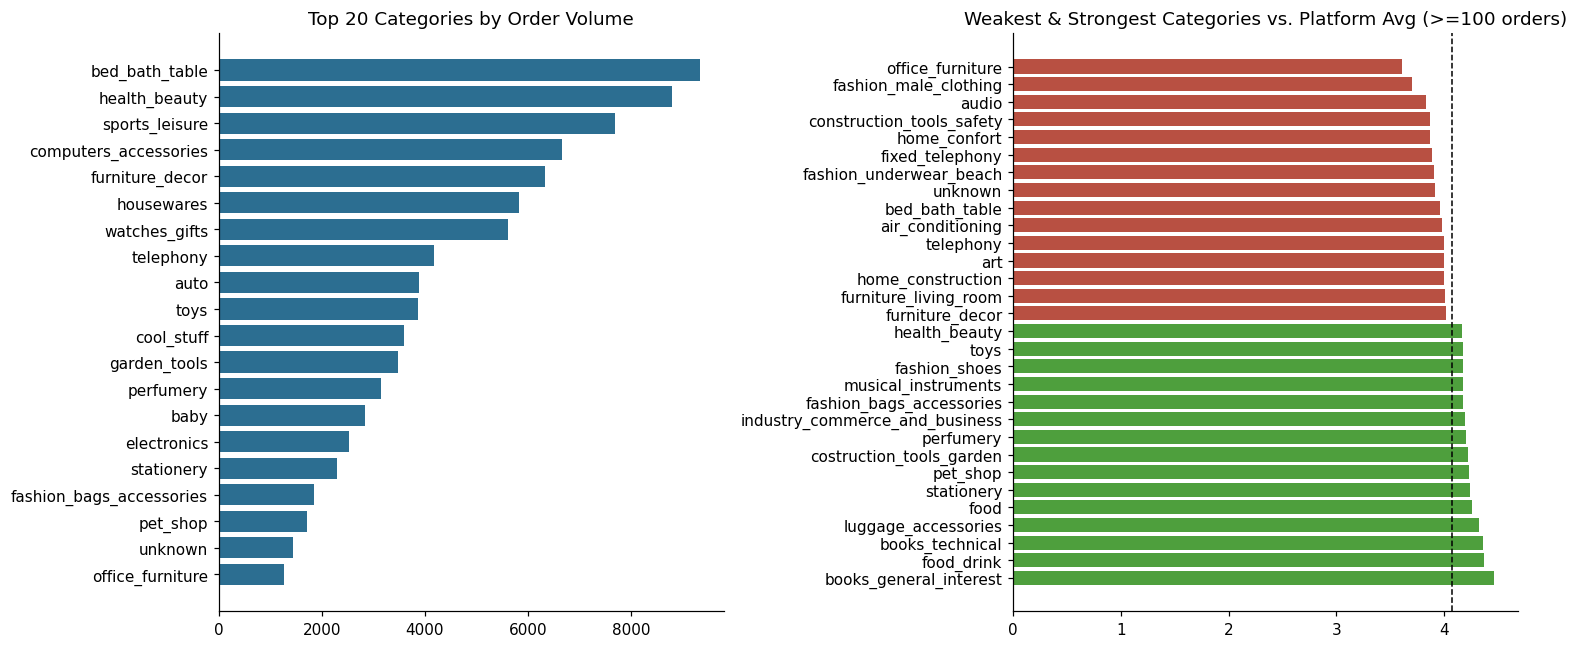

Platform average review score: 4.071


In [12]:
cat_perf = master.groupby('product_category_name_english').agg(
    orders=('order_id','count'),
    avg_price=('item_price_total','mean'),
    avg_review=('review_score','mean'),
).query('orders >= 100').sort_values('orders', ascending=False)

overall_avg_review = master['review_score'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14,6))
top20 = cat_perf.head(20)
axes[0].barh(top20.index, top20['orders'], color='#2C6E91')
axes[0].invert_yaxis(); axes[0].set_title('Top 20 Categories by Order Volume')

worst = cat_perf.sort_values('avg_review').head(15)
best  = cat_perf.sort_values('avg_review', ascending=False).head(15)
combo = pd.concat([worst, best]).sort_values('avg_review')
colors = ['#B85042' if v < overall_avg_review else '#4E9F3D' for v in combo['avg_review']]
axes[1].barh(combo.index, combo['avg_review'], color=colors)
axes[1].axvline(overall_avg_review, color='black', linestyle='--', linewidth=1)
axes[1].invert_yaxis(); axes[1].set_title('Weakest & Strongest Categories vs. Platform Avg (>=100 orders)')

plt.tight_layout(); plt.show()
print(f"Platform average review score: {overall_avg_review:.3f}")


## 8. Core Question 5 — Payment Behavior

              orders   avg_value  avg_review
payment_type                                
credit_card    74975  165.846112    4.072624
boleto         19784  143.663581    4.071421
voucher         3151  111.631070    3.983497
debit_card      1527  140.869496    4.159790
not_defined        3    0.000000    1.666667


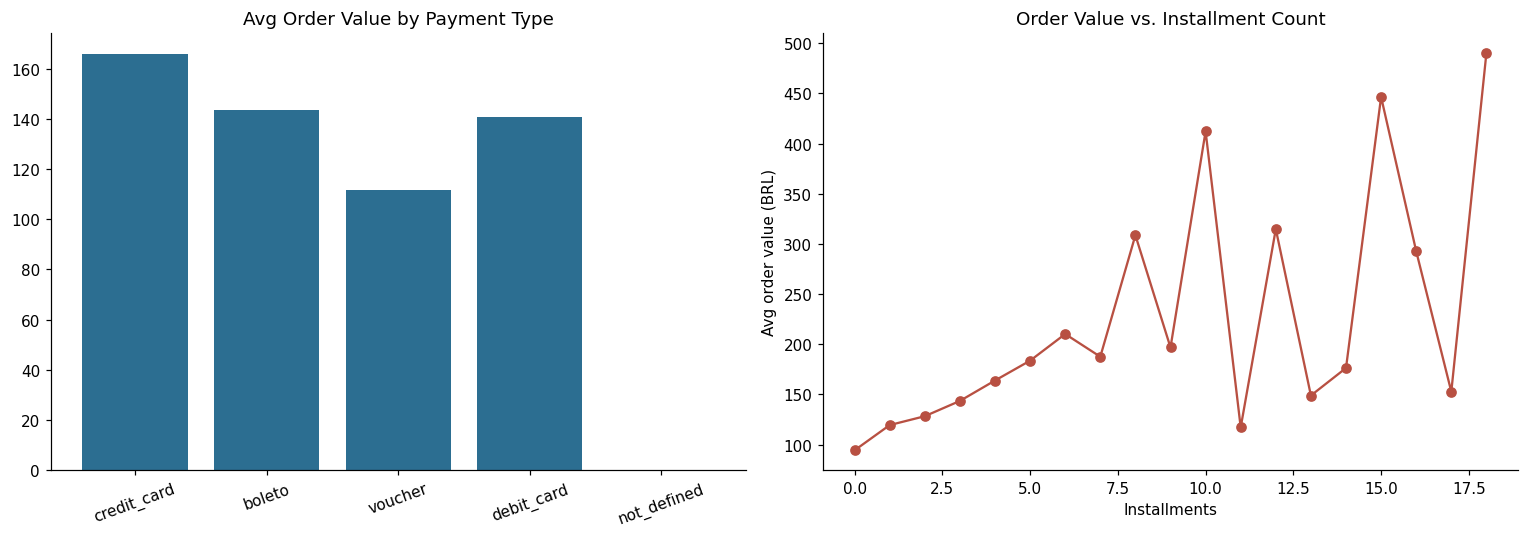

Correlation installments vs order value : 0.318
Correlation installments vs review score: -0.032


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

pay_type_stats = master.groupby('payment_type').agg(
    orders=('order_id','count'), avg_value=('order_value','mean'), avg_review=('review_score','mean')
).sort_values('orders', ascending=False)
print(pay_type_stats)

axes[0].bar(pay_type_stats.index, pay_type_stats['avg_value'], color='#2C6E91')
axes[0].set_title('Avg Order Value by Payment Type'); axes[0].tick_params(axis='x', rotation=20)

installments = master.dropna(subset=['max_installments','order_value'])
inst_stats = installments.groupby('max_installments')['order_value'].mean()
inst_stats = inst_stats[inst_stats.index <= 18]  # trim long tail of rare installment counts
axes[1].plot(inst_stats.index, inst_stats.values, marker='o', color='#B85042')
axes[1].set_xlabel('Installments'); axes[1].set_ylabel('Avg order value (BRL)')
axes[1].set_title('Order Value vs. Installment Count')

plt.tight_layout(); plt.show()

corr_inst_value = np.corrcoef(installments['max_installments'], installments['order_value'])[0,1]
corr_inst_review = np.corrcoef(installments['max_installments'],
                                installments['review_score'].fillna(installments['review_score'].mean()))[0,1]
print(f"Correlation installments vs order value : {corr_inst_value:.3f}")
print(f"Correlation installments vs review score: {corr_inst_review:.3f}")


## 9. Core Question 6 — Root Cause Analysis of Low Review Scores

Two complementary views:
1. **Mean-difference view** — how much the average review score shifts across key factors (delay, price tier, freight share, distance, installments).
2. **Multivariate view** — a NumPy ordinary-least-squares regression of `review_score` on standardized candidate drivers together, so we can see which factors carry a large coefficient *after* controlling for the others (a rough primary-vs-secondary signal, not a causal proof).

In [14]:
rc = (master.merge(dist_df[['order_id','distance_km']], on='order_id', how='left')
             .dropna(subset=['review_score','delivery_delay_days','order_value','freight_total','max_installments']))

rc['freight_share'] = rc['freight_total'] / rc['order_value'].replace(0, np.nan)
rc['is_late'] = (rc['delivery_delay_days'] > 0).astype(float)

factors = ['delivery_delay_days','freight_share','distance_km','max_installments','item_price_total']
rc_f = rc.dropna(subset=factors + ['review_score'])

print("Mean review score, low-delay vs high-delay orders:")
print(rc_f.groupby(pd.cut(rc_f['delivery_delay_days'], [-np.inf,0,np.inf], labels=['on-time/early','late']))['review_score'].mean())


Mean review score, low-delay vs high-delay orders:
delivery_delay_days
on-time/early    4.282969
late             2.544180
Name: review_score, dtype: float64


/tmp/ipykernel_4900/434709681.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(rc_f.groupby(pd.cut(rc_f['delivery_delay_days'], [-np.inf,0,np.inf], labels=['on-time/early','late']))['review_score'].mean())


R-squared: 0.082  (n=95,993)

Factor                   Standardized coef
Intercept                            4.142
delivery_delay_days                 -0.359
freight_share                       -0.065
distance_km                         -0.081
max_installments                    -0.043
item_price_total                    -0.058


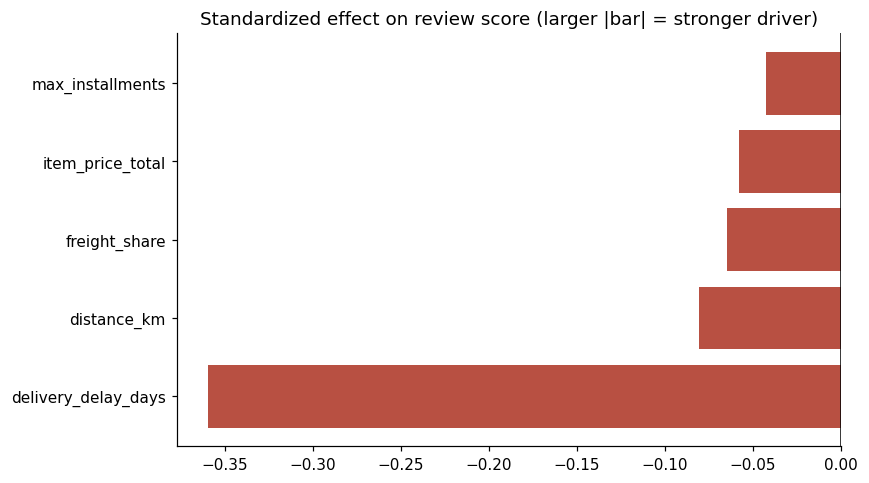

In [15]:
# NumPy multivariate OLS: standardize predictors, add intercept, solve via least squares
X_raw = rc_f[factors].to_numpy(dtype=float)
y = rc_f['review_score'].to_numpy(dtype=float)

X_mean, X_std = X_raw.mean(axis=0), X_raw.std(axis=0)
X_std_safe = np.where(X_std == 0, 1, X_std)
X_z = (X_raw - X_mean) / X_std_safe

X_design = np.column_stack([np.ones(len(X_z)), X_z])
coefs, residuals, rank, sv = np.linalg.lstsq(X_design, y, rcond=None)

pred = X_design @ coefs
ss_res = np.sum((y - pred)**2)
ss_tot = np.sum((y - y.mean())**2)
r2 = 1 - ss_res/ss_tot

print(f"R-squared: {r2:.3f}  (n={len(y):,})\n")
print(f"{'Factor':<22}{'Standardized coef':>20}")
print(f"{'Intercept':<22}{coefs[0]:>20.3f}")
for name, c in zip(factors, coefs[1:]):
    print(f"{name:<22}{c:>20.3f}")

fig, ax = plt.subplots(figsize=(8,4.5))
order_idx = np.argsort(np.abs(coefs[1:]))[::-1]
ax.barh(np.array(factors)[order_idx], coefs[1:][order_idx],
        color=['#B85042' if c < 0 else '#4E9F3D' for c in coefs[1:][order_idx]])
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Standardized effect on review score (larger |bar| = stronger driver)')
plt.tight_layout(); plt.show()


> **Reading this chart:** bars further from zero are stronger candidate drivers of review score once the other factors are held constant. A negative bar means higher values of that factor are associated with *lower* review scores. This is descriptive/associative, not causal — run this cell against the real data before quoting numbers to leadership.

## 10. Optional Deep Dives (run if time allows)

### 10a. Repeat customers (`customer_unique_id` vs `customer_id`)

In [ ]:
cust_orders = master 
repeat_counts = cust_orders.groupby('customer_unique_id')['order_id'].nunique()

repeat_dist = repeat_counts.value_counts().sort_index()
print(repeat_dist.head(10))

repeaters = repeat_counts[repeat_counts > 1].index
is_repeat = cust_orders['customer_unique_id'].isin(repeaters)
print(f"\nShare of orders from repeat customers: {is_repeat.mean()*100:.1f}%")
print(f"Avg order value — one-time buyers: {cust_orders.loc[~is_repeat,'order_value'].mean():.2f} BRL")
print(f"Avg order value — repeat buyers  : {cust_orders.loc[is_repeat,'order_value'].mean():.2f} BRL")


order_id
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

Share of orders from repeat customers: 6.4%
Avg order value — one-time buyers: 160.28 BRL
Avg order value — repeat buyers  : 145.39 BRL


### 10b. Seller-level performance (controlling for category)

Sellers with >=30 orders: 630
            orders  avg_review   avg_delay
count   630.000000  630.000000  630.000000
mean    130.334921    4.117541  -11.424019
std     201.716057    0.316274    3.215113
min      30.000000    2.321739  -42.754252
25%      43.000000    3.937621  -13.051328
50%      67.000000    4.147900  -11.033540
75%     128.000000    4.326293   -9.510765
max    1836.000000    5.000000    2.627415


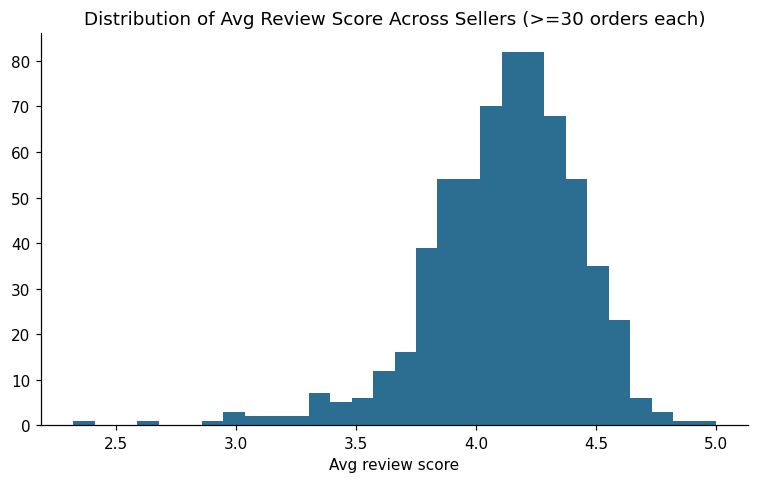

In [17]:
seller_perf = master.dropna(subset=['seller_id']).groupby('seller_id').agg(
    orders=('order_id','count'),
    avg_review=('review_score','mean'),
    avg_delay=('delivery_delay_days','mean'),
).query('orders >= 30').sort_values('avg_review')

print(f"Sellers with >=30 orders: {len(seller_perf):,}")
print(seller_perf.describe())

fig, ax = plt.subplots(figsize=(7,4.5))
ax.hist(seller_perf['avg_review'], bins=30, color='#2C6E91')
ax.set_title('Distribution of Avg Review Score Across Sellers (>=30 orders each)')
ax.set_xlabel('Avg review score')
plt.tight_layout(); plt.show()
